# Week 2 — Exploratory Data Analysis (EDA): Agribusiness Dataset

Detailed EDA of the cleaned Week 1 dataset. The analysis examines distributions, categorical patterns, relationships, correlations, anomalies, and agribusiness efficiency indicators.

**Note:** The dataset has 50 farms, so findings are exploratory. Correlation does not imply causation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("cleaned_agriculture_dataset.csv")
print("Shape:", df.shape)
display(df.head())

Shape: (50, 10)


,farm_id,crop_type,farm_area_acres,irrigation_type,fertilizer_used_tons,pesticide_used_kg,yield_tons,soil_type,season,water_usage_cubic_meters
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69


## 1. Dataset Overview

In [2]:
display(df.dtypes.to_frame("data_type"))
display(df.describe().T)
display(df.isna().sum().to_frame("missing_values"))

,data_type
farm_id,object
crop_type,object
farm_area_acres,float64
irrigation_type,object
fertilizer_used_tons,float64
pesticide_used_kg,float64
yield_tons,float64
soil_type,object
season,object
water_usage_cubic_meters,float64


,count,mean,std,min,25%,50%,75%,max
farm_area_acres,50.0,254.9638,139.417782,12.50,135.7100,281.980,368.1075,483.88
fertilizer_used_tons,50.0,4.9054,2.732689,0.50,2.4375,5.045,6.8850,9.96
pesticide_used_kg,50.0,2.3980,1.438613,0.14,0.9725,2.330,3.4175,4.99
yield_tons,50.0,27.0592,13.345789,3.86,16.1900,28.970,37.8600,48.02
water_usage_cubic_meters,50.0,56724.2956,27264.992053,5869.75,37818.1525,54097.075,82240.0325,94754.73


,missing_values
farm_id,0
crop_type,0
farm_area_acres,0
irrigation_type,0
fertilizer_used_tons,0
pesticide_used_kg,0
yield_tons,0
soil_type,0
season,0
water_usage_cubic_meters,0


## 2. Numerical Distributions

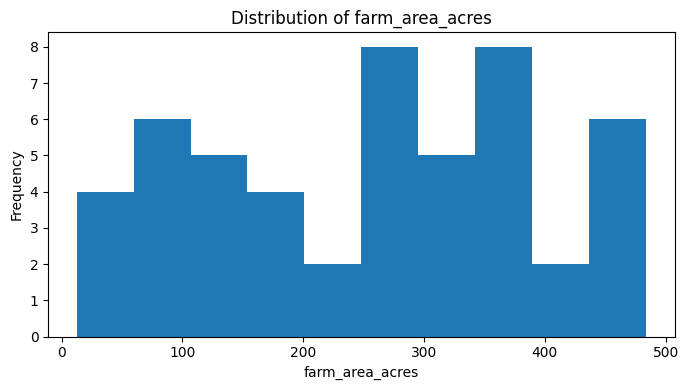

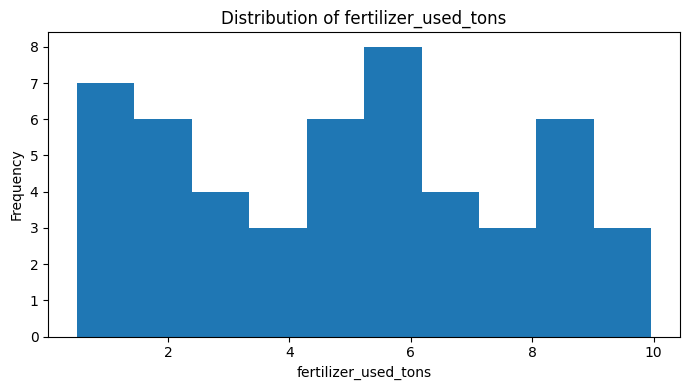

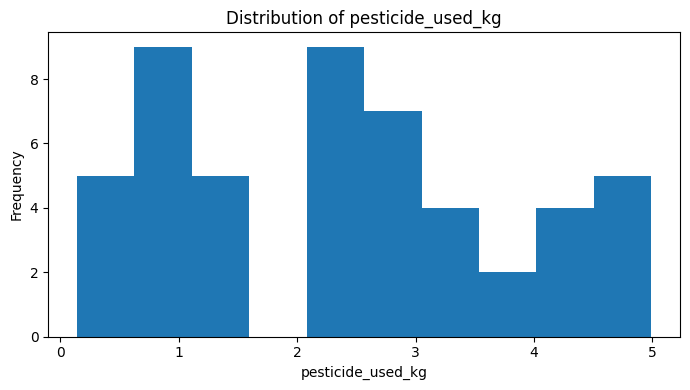

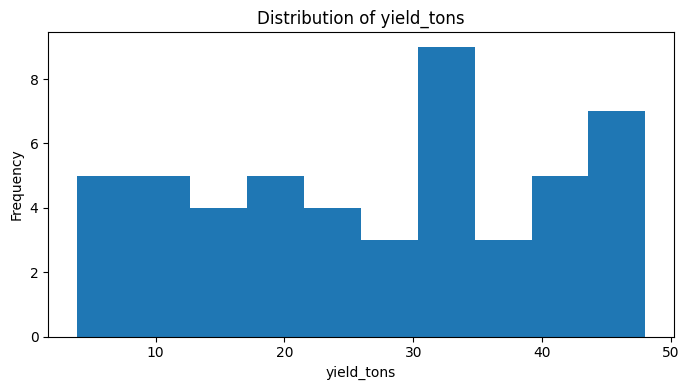

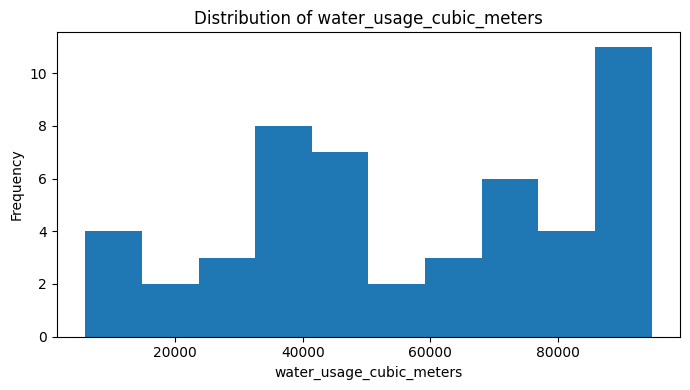

In [3]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(7,4))
    plt.hist(df[col], bins=10)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col); plt.ylabel("Frequency")
    plt.tight_layout(); plt.show()

## 3. Categorical Distributions

,count
farm_id,
F001,1
F002,1
F003,1
F004,1
F005,1
F006,1
F007,1
F008,1
F009,1


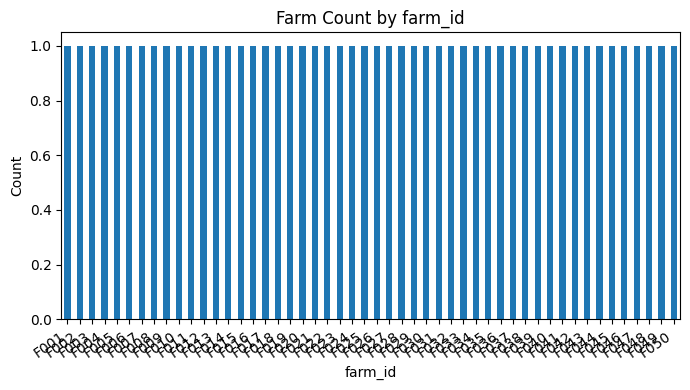

,count
crop_type,
Cotton,7
Barley,7
Tomato,6
Rice,5
Soybean,5
Sugarcane,5
Carrot,4
Wheat,4
Potato,4


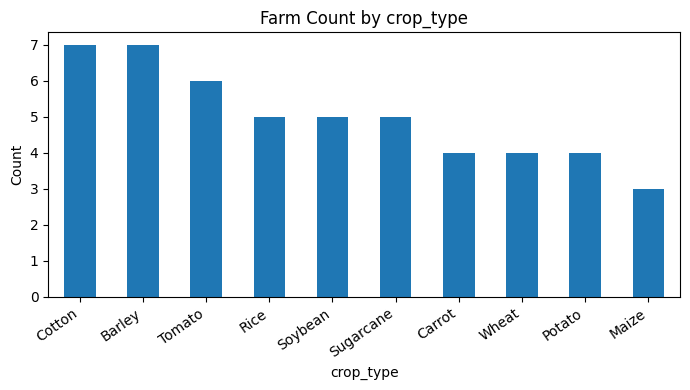

,count
irrigation_type,
Drip,15
Flood,13
Sprinkler,9
Rain-fed,7
Manual,6


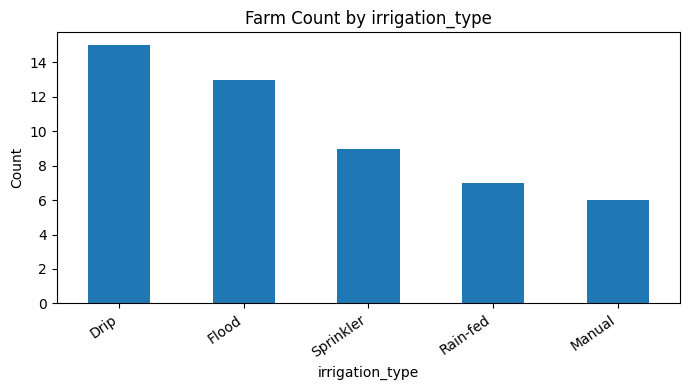

,count
soil_type,
Clay,14
Loamy,11
Sandy,11
Silty,10
Peaty,4


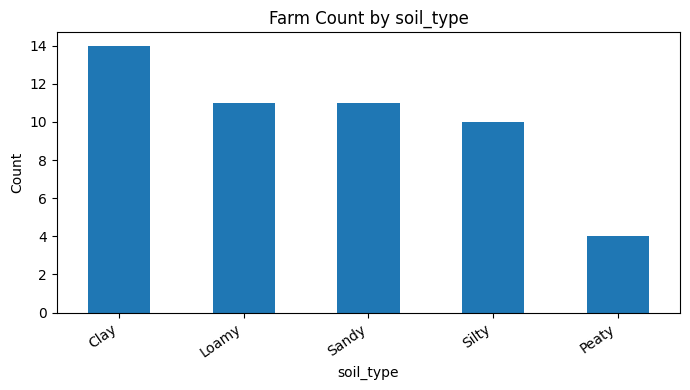

,count
season,
Zaid,23
Kharif,16
Rabi,11


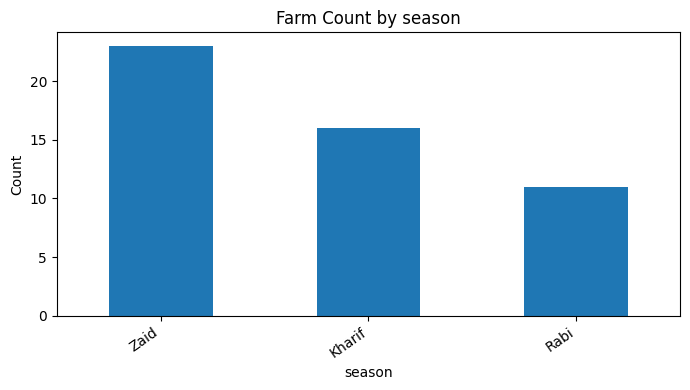

In [4]:
for col in df.select_dtypes(include="object").columns:
    display(df[col].value_counts().to_frame("count"))
    df[col].value_counts().plot(kind="bar", figsize=(7,4))
    plt.title(f"Farm Count by {col}")
    plt.ylabel("Count"); plt.xticks(rotation=35, ha="right")
    plt.tight_layout(); plt.show()

## 4. Average Yield by Farm Characteristics

,average_yield_tons
crop_type,
Carrot,36.630000
Tomato,33.630000
Soybean,32.310000
Sugarcane,26.952000
Barley,26.401429
Potato,25.157500
Wheat,24.417500
Rice,23.586000
Cotton,20.974286


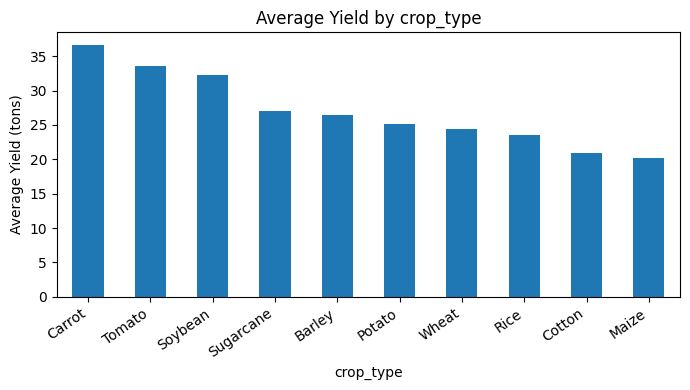

,average_yield_tons
irrigation_type,
Manual,34.160000
Rain-fed,31.980000
Sprinkler,27.887778
Drip,26.769333
Flood,20.893077


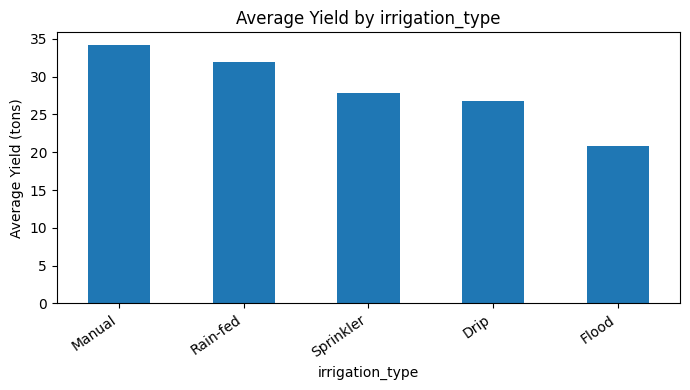

,average_yield_tons
soil_type,
Silty,30.888000
Loamy,27.483636
Sandy,27.026364
Clay,25.042143
Peaty,23.470000


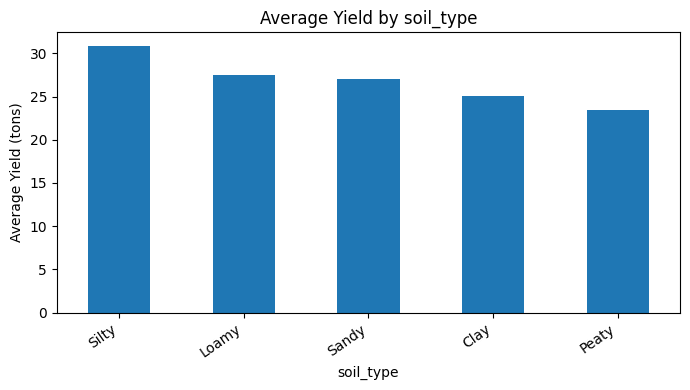

,average_yield_tons
season,
Zaid,28.004348
Kharif,27.341875
Rabi,24.671818


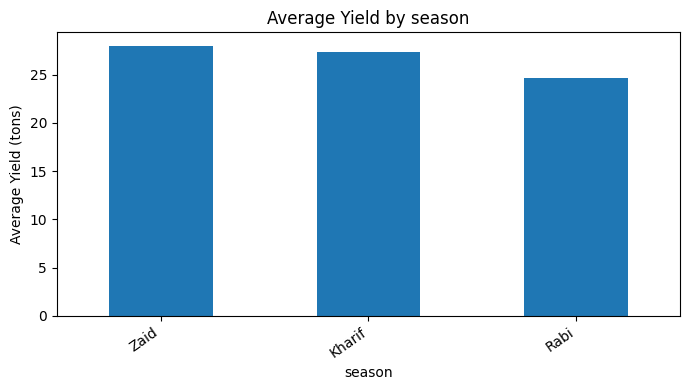

In [5]:
for col in ["crop_type","irrigation_type","soil_type","season"]:
    means=df.groupby(col)["yield_tons"].mean().sort_values(ascending=False)
    display(means.to_frame("average_yield_tons"))
    means.plot(kind="bar", figsize=(7,4))
    plt.title(f"Average Yield by {col}")
    plt.ylabel("Average Yield (tons)")
    plt.xticks(rotation=35,ha="right"); plt.tight_layout(); plt.show()

## 5. Correlation and Relationships

water_usage_cubic_meters vs yield_tons: Pearson r = 0.108


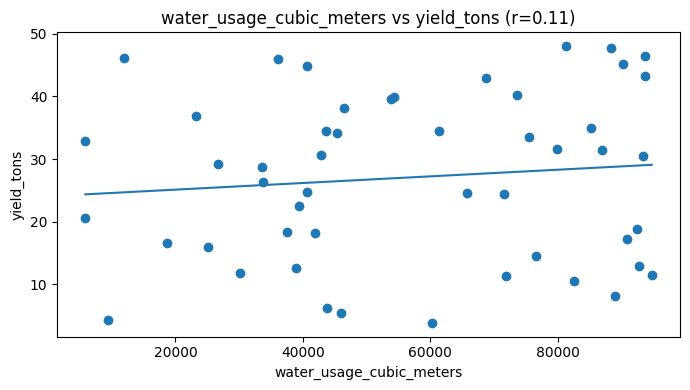

fertilizer_used_tons vs yield_tons: Pearson r = 0.045


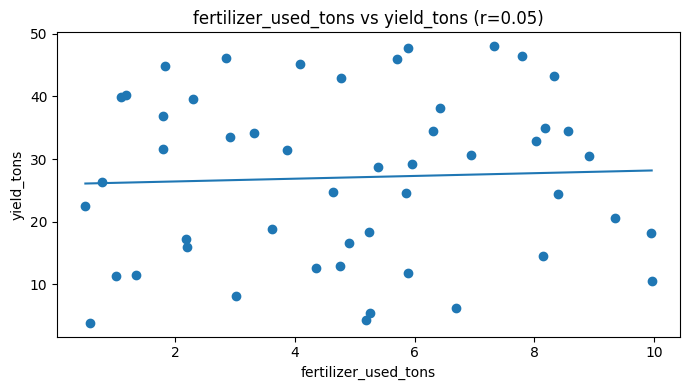

farm_area_acres vs yield_tons: Pearson r = 0.153


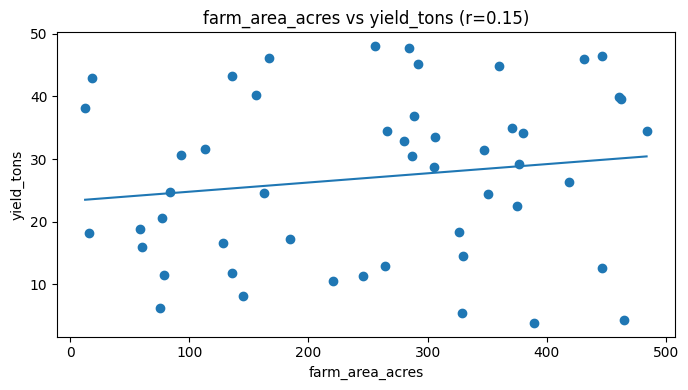

pesticide_used_kg vs yield_tons: Pearson r = -0.090


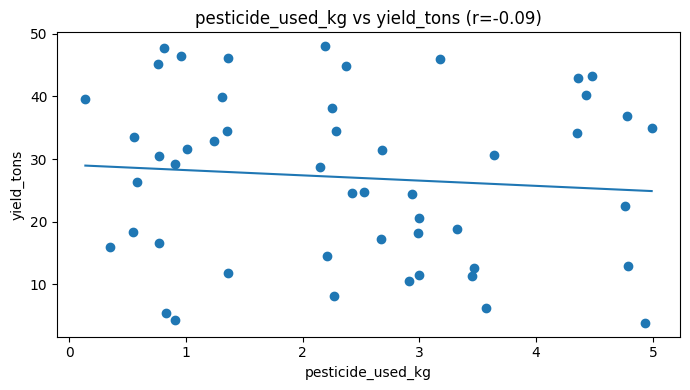

In [6]:
pairs=[("water_usage_cubic_meters","yield_tons"),("fertilizer_used_tons","yield_tons"),("farm_area_acres","yield_tons"),("pesticide_used_kg","yield_tons")]
for x,y in pairs:
    r=df[x].corr(df[y])
    print(f"{x} vs {y}: Pearson r = {r:.3f}")
    plt.figure(figsize=(7,4)); plt.scatter(df[x],df[y])
    z=np.polyfit(df[x],df[y],1); xs=np.linspace(df[x].min(),df[x].max(),100)
    plt.plot(xs,np.poly1d(z)(xs))
    plt.title(f"{x} vs {y} (r={r:.2f})"); plt.xlabel(x); plt.ylabel(y)
    plt.tight_layout(); plt.show()

## 6. Correlation Heatmap

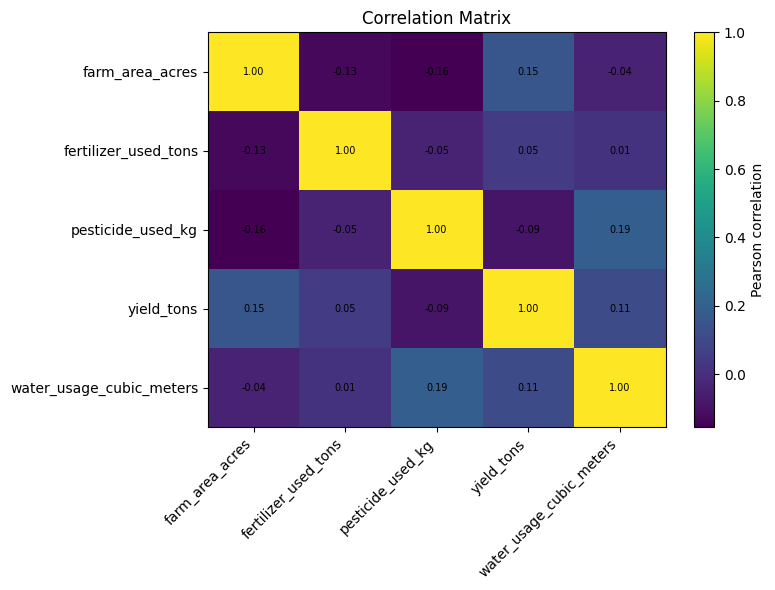

In [7]:
corr=df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8,6)); plt.imshow(corr,aspect="auto"); plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45,ha="right")
plt.yticks(range(len(corr.columns)),corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)): plt.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7)
plt.title("Correlation Matrix"); plt.tight_layout(); plt.show()

## 7. Agribusiness Efficiency Indicators

In [8]:
eda=df.copy()
eda["yield_per_acre"]=eda["yield_tons"]/eda["farm_area_acres"]
eda["fertilizer_per_acre"]=eda["fertilizer_used_tons"]/eda["farm_area_acres"]
eda["pesticide_per_acre"]=eda["pesticide_used_kg"]/eda["farm_area_acres"]
eda["water_per_acre"]=eda["water_usage_cubic_meters"]/eda["farm_area_acres"]
display(eda[["yield_per_acre","fertilizer_per_acre","pesticide_per_acre","water_per_acre"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
yield_per_acre,50.0,0.249780,0.533792,0.009105,0.069899,0.105233,0.182567,3.054400
fertilizer_per_acre,50.0,0.051727,0.115630,0.001333,0.011114,0.017550,0.036287,0.634971
pesticide_per_acre,50.0,0.024225,0.047357,0.000303,0.004505,0.008469,0.016331,0.233530
water_per_acre,50.0,483.308098,796.086558,20.216057,115.145429,231.246748,451.328170,3719.038400


## 8. IQR Anomaly Review

In [9]:
for col in df.select_dtypes(include=np.number).columns:
    q1=df[col].quantile(.25); q3=df[col].quantile(.75); iqr=q3-q1
    lo=q1-1.5*iqr; hi=q3+1.5*iqr
    n=((df[col]<lo)|(df[col]>hi)).sum()
    print(f"{col}: {n} IQR outliers; bounds=({lo:.2f}, {hi:.2f})")

farm_area_acres: 0 IQR outliers; bounds=(-212.89, 716.70)
fertilizer_used_tons: 0 IQR outliers; bounds=(-4.23, 13.56)
pesticide_used_kg: 0 IQR outliers; bounds=(-2.70, 7.09)
yield_tons: 0 IQR outliers; bounds=(-16.31, 70.36)
water_usage_cubic_meters: 0 IQR outliers; bounds=(-28814.67, 148872.85)


## 9. Key Conclusions

- Numerical distributions describe farm and resource variability.
- Categorical analysis describes crop, irrigation, soil, and seasonal composition.
- Grouped yield analysis reveals observed differences between categories.
- Pearson correlations quantify linear associations between yield and numerical variables.
- Yield per acre and resource-use-per-acre measures support efficiency analysis.
- No IQR-based numerical anomalies are expected from the cleaned Week 1 dataset.
- The sample is small, so findings are exploratory and not broadly generalizable.

In [10]:
eda.to_csv("week2_eda_dataset.csv", index=False)
print("Saved week2_eda_dataset.csv")

Saved week2_eda_dataset.csv
